# TNImpact: Predictive Engine Intelligence Output
### ML Model Visualization & Heatmap Analysis

This notebook provides a deep-dive analysis into the **RF-Traffic-v2.1** model. We leverage `matplotlib` and `seaborn` to visualize the primary features driving our logistics optimization.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Set aesthetic style
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

## 1. Load Data & Engine Model

In [10]:
dataset_path = '/Users/sureshkumar/prime project/tnimpact/data/traffic_data.csv'
model_path = '/Users/sureshkumar/prime project/tnimpact/app/models/tn_route_model_v2.pkl'

df = pd.read_csv(dataset_path)
model = joblib.load(model_path)

print(f"Dataset Rows: {len(df)}")
df.head()

Dataset Rows: 5000


,distance_km,hour,day_of_week,road_type,historical_speed,traffic_multiplier
0,8.98,17,3,1,37.35,2.04
1,16.71,0,3,0,28.17,1.18
2,14.73,2,6,0,41.45,1.00
3,4.53,21,0,0,41.26,1.19
4,16.80,5,6,0,40.51,1.08


## 2. Feature Importance Analysis
Visualizing which signals (Hour, Road Type, etc.) carry the most weight in our ETA predictions.

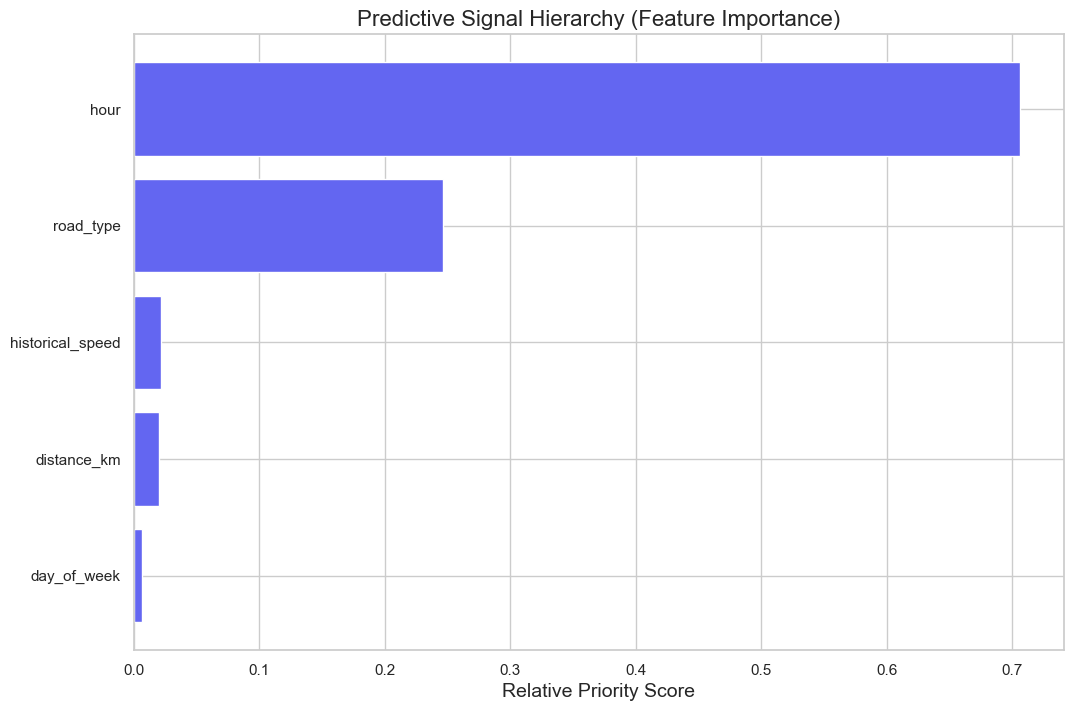

In [11]:
features = ['distance_km', 'hour', 'day_of_week', 'road_type', 'historical_speed']
importances = model.feature_importances_
indices = np.argsort(importances)

plt.title('Predictive Signal Hierarchy (Feature Importance)')
plt.barh(range(len(indices)), importances[indices], color='#6366f1', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Priority Score')
plt.show()

## 3. Correlation Heatmap
Analyzing the relationship between input features and the target `traffic_multiplier`.

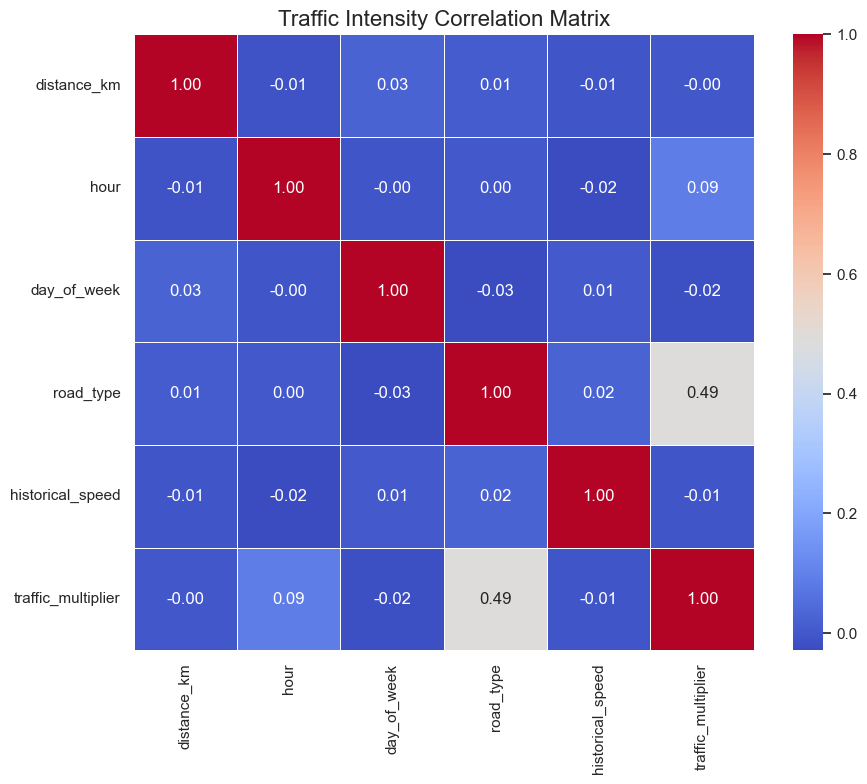

In [12]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Traffic Intensity Correlation Matrix')
plt.show()

## 4. Traffic Density Heatmap (Hour vs Day)
Identifying high-risk temporal zones for the logistics fleet.

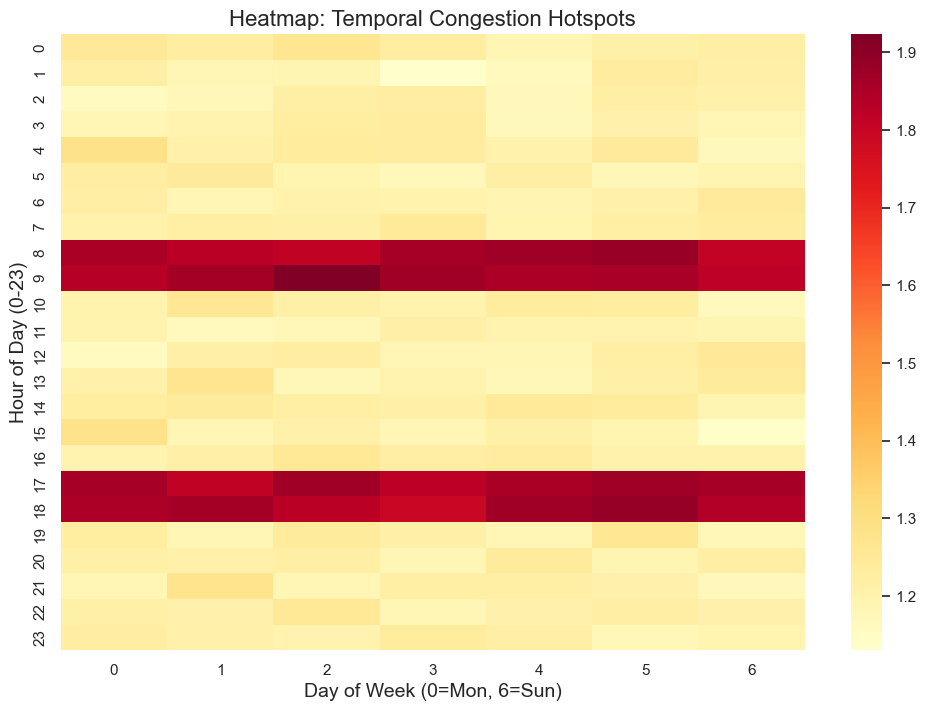

In [13]:
pivot_table = df.pivot_table(index='hour', columns='day_of_week', values='traffic_multiplier', aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='YlOrRd', annot=False)
plt.title('Heatmap: Temporal Congestion Hotspots')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Hour of Day (0-23)')
plt.show()

## 5. Actual vs Predicted Scatter Plot

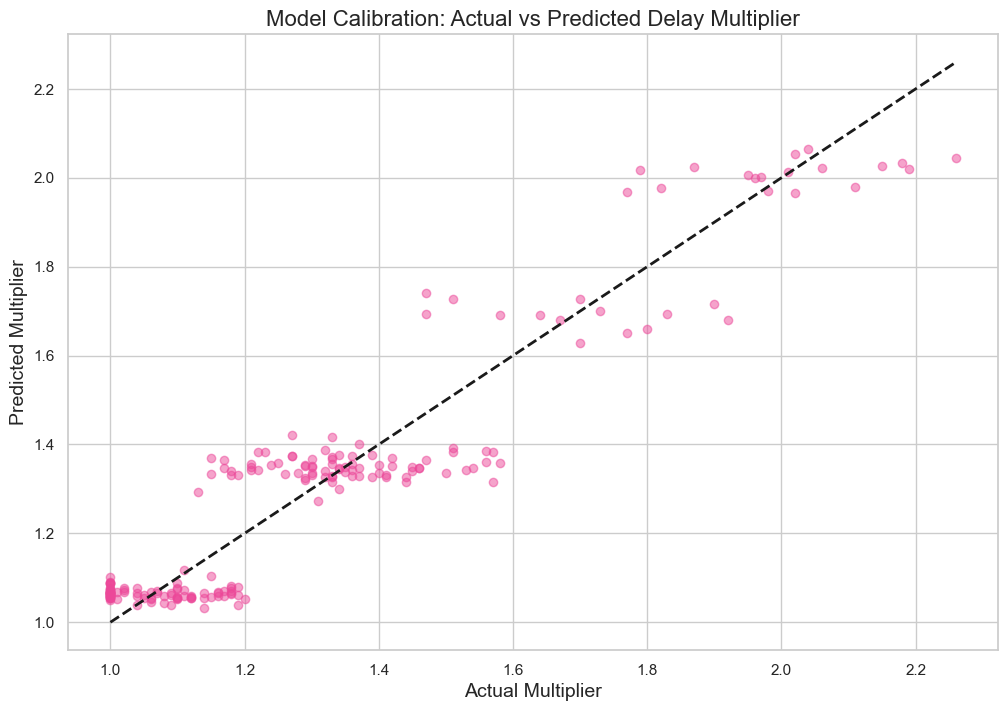

In [8]:
X = df[features]
y = df['traffic_multiplier']
y_pred = model.predict(X.tail(200)) # Sample for visibility
y_true = y.tail(200)

plt.scatter(y_true, y_pred, alpha=0.5, color='#ec4899')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
plt.title('Model Calibration: Actual vs Predicted Delay Multiplier')
plt.xlabel('Actual Multiplier')
plt.ylabel('Predicted Multiplier')
plt.show()